In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sympy.physics.wigner import wigner_3j, wigner_6j
from scipy import linalg
from sympy import Matrix
from tqdm import tqdm

In [91]:
hbar = 6.62607015*10**-34 / (2*np.pi) # Joules seconds
h = hbar*2*np.pi # J seconds
u_B = 9.274010e-24 # J/T

In [113]:
# 5²S₁/₂ ground state parameters
S_ground = {
    'J': 1/2,
    'L': 0,
    'F': [1, 2], # F = |I-J| to |I+J|, here I=3/2
    'A_hfs': h*3.417341e9, # J
    'B_hfs': 0, # J
    'g_J': 2.00233113,
    'g_I': -0.0009951414,
    'B': np.linspace(0, 15000/10000, 1000), # T, for ground state 5S_1/2
}

# 5²P₁/₂ D1 excited state parameters
P_12 = {
    'J': 1/2,
    'L': 1,
    'F': [1, 2], # F = |I-J| to |I+J|, here I=3/2
    'A_hfs': h*407.25e6,  # J
    'B_hfs': 0, # J
    'g_J': 0.666,
    'g_I': -0.0009951414,
    'B': np.linspace(0, 5000/10000, 1000), # T, for excited state 5P_1/2
}

# 5²P₃/₂ D2 excited state parameters
P_32 = {
    'J': 3/2,
    'L': 1,
    'F': [0, 1, 2, 3], # F = |I-J| to |I+J|, here I=3/2
    'A_hfs': h*84.7185e6, # J
    'g_J': 1.3362,
    'g_I': -0.0009951414,
    'B': np.linspace(0, 500/10000, 1000), # T, for excited state 5P_3/2
    'B_hfs': h*12.4965e6 # J, for 2P_3/2, include electric quadrupole term (no longer negligible)
}

In [93]:
def get_L_term(L, F, F_p, M, M_p, J, I, S):
    power_term = (-1)**(J+L+S+1+F_p+J+I+1+F-M)
    sqrt_terms = np.sqrt((2*F+1)*(2*F_p+1))*np.sqrt(L*(L+1)*(2*L+1))
    return power_term*(2*J+1)*sqrt_terms*hbar*wigner_3j(F,1,F_p,-M,0,M_p)*wigner_6j(J,F_p,I,F,J,1)*wigner_6j(L,J,S,J,L,1)

def get_S_term(S, F, F_p, M, M_p, J, I, L):
    power_term = (-1)**(F-M+F_p+J+I+J+S+L+1+1)
    sqrt_terms = np.sqrt((2*F+1)*(2*F_p+1))*np.sqrt((2*J+1)*(2*J+1))*np.sqrt(S*(S+1)*(2*S+1))
    return power_term*sqrt_terms*hbar*wigner_3j(F,1,F_p,-M,0,M_p)*wigner_6j(J,F_p,I,F,J,1)*wigner_6j(S,J,L,J,S,1)

def get_I_term(I, F, F_p, M, M_p, J):
    power_term = (-1)**(F_p+I+J+F-M+1)
    sqrt_terms = np.sqrt((2*F+1)*(2*F_p+1))*np.sqrt(I*(I+1)*(2*I+1))
    return power_term*sqrt_terms*hbar*wigner_3j(F,1,F_p,-M,0,M_p)*wigner_6j(I,F_p,J,F,I,1)

In [ ]:
state_params = P_12
A_hfs = state_params['A_hfs']
B_hfs = state_params['B_hfs']
B = state_params['B']
J = state_params['J']
L = state_params['L']
F_vals = state_params['F']
I, S = 3/2, 1/2

In [ ]:
# for a given energy (M, M') in the matrix
def get_matrix_element(M, M_p, F, F_p, I, J, L, S, B):
    hyperfine_element = 0
    K = F*(F+1)-I*(I+1)-J*(J+1)
    if (F == F_p) & (M==M_p):
        hyperfine_element += A_hfs/(hbar**2)*K*hbar**2/2 
        #hyperfine_element += B_hfs/(hbar**2)*(3/2*K*(K+1)-2*I*(I+1)*J*(J+1))/(4*I*(2*I-1)*J*(2*J-1))*hbar**2
       
    # Values from Steck (unitless)
    g_L = 0.99999339
    g_S = 2.002319304
    g_I = -0.0009951414

    L_term = -u_B*B/hbar*g_L*get_L_term(L, F, F_p, M, M_p, J, I, S)
    S_term = -u_B*B/hbar*g_S*get_S_term(S, F, F_p, M, M_p, J, I, L)
    I_term = -u_B*B/hbar*g_I*get_I_term(I, F, F_p, M, M_p, J)

    spherical_elements = L_term + S_term + I_term

    return spherical_elements + hyperfine_element

In [104]:
def get_H(size, Fv, F_pv, Mv, M_pv, I, J, L, S, B_val):
    H = np.zeros((size, size))
    for i in range(0, size):
        for j in range(0, size):
            F, F_p = Fv[i,j], F_pv[i,j]
            M, M_p = Mv[i,j], M_pv[i,j]
            H[i][j] = get_matrix_element(M, M_p, F, F_p, I, J, L, S, B_val)
    return H

In [ ]:
def create_FM_arrays(F_values):
    F_array, M_array = [], []
    for F in F_values:
        F_array.extend([F] * int(2*F+1))
        M_array.extend(np.arange(-F, F+1))  # works for both integer and half-integer F
    
    return np.array(F_array), np.array(M_array)

In [ ]:
F, M = create_FM_arrays(F_vals)
size = len(F)
M_pv, Mv = np.meshgrid(M, M)
F_pv, Fv = np.meshgrid(F, F)

#print(M_pv)
#print(Mv)
#print(F_pv)
#print(Fv)

eig_arr = []
for i in tqdm(range(0, len(B))):
    B_val = B[i]
    H = get_H(size, Fv, F_pv, Mv, M_pv, I, J, L, S, B_val)
    eigenvalues, eigenvectors = linalg.eigh(H)
    eig_arr.append(eigenvalues)

100%|██████████| 1000/1000 [04:49<00:00,  3.45it/s]


In [98]:
Matrix(H)

Matrix([
[-1.11500420924476e-24,                     0,                    0,                    0, -1.3350199234893e-24,                     0,                     0,                     0],
[                    0, -3.37308383573437e-25,                    0,                    0,                    0, -1.54154822440013e-24,                     0,                     0],
[                    0,                     0, 4.40387442097886e-25,                    0,                    0,                     0,  -1.3350199234893e-24,                     0],
[                    0,                     0,                    0, 1.73931877889668e-24,                    0,                     0,                     0,                     0],
[ -1.3350199234893e-24,                     0,                    0,                    0, 9.70851904520372e-25,                     0,                     0,                     0],
[                    0, -1.54154822440013e-24,                    0,        

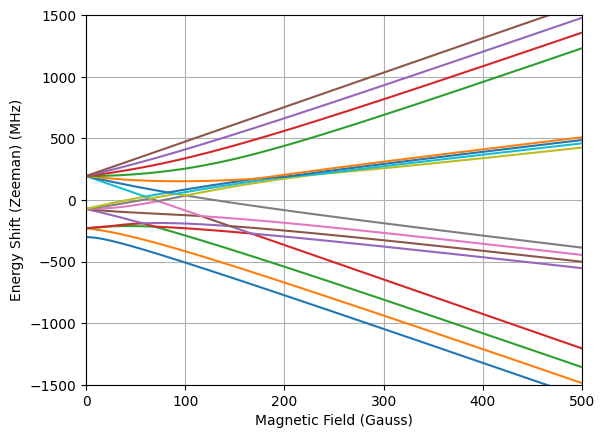

In [107]:
eig_arr = np.array(eig_arr)

for i in range(0, size):
    plt.plot(B*10000, eig_arr[:,i]/h/1e6, '-', markersize=1)

plt.ylim([-25, 25]); plt.xlim([0, 15000])
plt.ylim([-2.5, 2.5]); plt.xlim([0, 5000])
plt.ylim([-1500, 1500]); plt.xlim([0, 500])

plt.xlabel('Magnetic Field (Gauss)')
plt.ylabel('Energy Shift (Zeeman) (MHz)')
plt.grid()